[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/notebooks/EN/chapter4_lecture_notebook.ipynb)

# Statistics of Financial Markets — Chapter 4: Probability

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Random variables, distributions, expectation, variance, covariance and correlation on real returns.
- Independence vs uncorrelatedness, conditional expectation and conditional variance (the basis of GARCH).
- Random numbers, the inverse transform and Monte Carlo; the binomial process; white noise, random walk, AR(1).
- The Wiener process and geometric Brownian motion (GBM) against real paths of the S&P 500, the BET and Bitcoin.
- Textbook: Franke, Härdle and Hafner (2019), *Statistics of Financial Markets*, 5th ed., Ch. 3-5.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_4'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/SFM - Statistica pietelor financiare/2026/notebooks/EN


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the SFM repository (read locally, or from GitHub in Colab); EUR/RON is the official BNR reference rate.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the SFM repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years

## Definitions used in the whole notebook

- `returns(name)`: daily log returns in %, from 2000 (or from the first day of the series).
- `joint_returns(a, b)`: returns of two series on their common trading days (prices joined first).
- `gbm_params(r)`: annual log drift, volatility and arithmetic drift $\mu = \mu_{\log} + \sigma^2/2$; `simulate_gbm`: exact GBM simulation.
- `lcg`, `randu`: linear congruential generators; `binomial_crr`: the Cox-Ross-Rubinstein tree; `ar1`: AR(1).
- `max_drawdown`: the largest fall from a running peak, $\min_t(P_t/\max_{s\le t}P_s - 1)$.

In [5]:
START = '2000-01-01'
ASSETS = ['sp500', 'dax', 'bet', 'btc']
COLORS = {'sp500': '#1A3A6E', 'dax': '#17A2B8', 'bet': '#CD0000', 'btc': '#B5853F'}
SHORT = {'sp500': 'S&P 500', 'dax': 'DAX', 'bet': 'BET', 'btc': 'Bitcoin'}
PAL = {'blue': '#1A3A6E', 'red': '#CD0000', 'green': '#2E7D32', 'amber': '#B5853F', 'purple': '#8E44AD', 'teal': '#17A2B8', 'orange': '#E67E22', 'crimson': '#DC3545'}
RANDU_A, RANDU_M = 65539, 2147483648


def returns(name, start=START, end=None):
    """Daily log returns in %, from `start` or from the first day of the series if that is later."""
    s0 = max(start, SERIES[name][4])
    return log_returns(name, s0) if end is None else log_returns(name, s0, end)


def joint_returns(a, b, start=START):
    """Daily log returns (%) of two series on their common trading days: join the prices first, then difference."""
    p = load_panel([a, b], start=start).dropna()
    return (100 * np.log(p).diff()).dropna()


def acf(x, nlags=20):
    """Sample autocorrelation function rho(1), ..., rho(nlags)."""
    x = np.asarray(x, dtype=float) - np.mean(x)
    d = np.sum(x * x)
    return np.array([np.sum(x[h:] * x[:-h]) / d for h in range(1, nlags + 1)])


def max_drawdown(prices):
    """Maximum drawdown of a price path: the largest fall from a running peak, min_t (P_t / max_{s<=t} P_s - 1)."""
    p = np.asarray(prices, dtype=float)
    return float(np.min(p / np.maximum.accumulate(p) - 1))


def gbm_params(r, ppy=None):
    """Calibrate GBM to daily log returns r (in %): annual log drift mu_log, volatility sigma, arithmetic drift
    mu = mu_log + sigma^2/2 (so that E[S_t] = S_0 exp(mu t) and median S_0 exp(mu_log t))."""
    r = pd.Series(r).dropna() / 100
    ppy = ppy or periods_per_year(r)
    m, s = r.mean() * ppy, r.std() * np.sqrt(ppy)
    return {'mu_log': m, 'sigma': s, 'mu': m + s ** 2 / 2, 'ppy': ppy, 'n': len(r)}


def simulate_gbm(S0, mu, sigma, T, steps, n_paths, seed=0):
    """Exact simulation of GBM: S_{t+dt} = S_t exp((mu - sigma^2/2) dt + sigma sqrt(dt) Z), Z ~ N(0, 1).
    Returns an array (n_paths, steps + 1). Port of SFEsimGBM."""
    rng = np.random.default_rng(seed)
    dt = T / steps
    z = rng.standard_normal((n_paths, steps))
    logp = np.cumsum((mu - sigma ** 2 / 2) * dt + sigma * np.sqrt(dt) * z, axis=1)
    return S0 * np.exp(np.hstack([np.zeros((n_paths, 1)), logp]))


def lcg(a, c, M, seed, n):
    """Linear congruential generator x_{k+1} = (a x_k + c) mod M; returns the integers and the uniforms x/M.
    Port of SFErangen1/SFErangen2."""
    x = np.empty(n, dtype=np.int64)
    x[0] = seed
    for k in range(1, n):
        x[k] = (a * int(x[k - 1]) + c) % M
    return x, x / M


def lcg_period(a, c, M, seed):
    """Length of the cycle of an LCG started at `seed`."""
    seen, x, k = {}, seed, 0
    while x not in seen:
        seen[x] = k
        x = (a * x + c) % M
        k += 1
    return k - seen[x]


def randu(n, seed=1):
    """The RANDU generator (multiplier 65539, modulus 2^31, odd seed). Port of SFErandu."""
    return lcg(RANDU_A, 0, RANDU_M, seed, n)


def binomial_crr(S0, mu, sigma, T, n):
    """Cox-Ross-Rubinstein binomial process: n steps of length dt = T/n, up factor u = exp(sigma sqrt(dt)),
    down factor d = 1/u, probability of an up move p = (exp(mu dt) - d) / (u - d), so that E[S_{t+dt}] = S_t exp(mu dt).
    Returns the terminal values S_0 u^k d^(n-k), their probabilities and the parameters. Port of SFEBinomp."""
    dt = T / n
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(mu * dt) - d) / (u - d)
    k = np.arange(n + 1)
    return {'S': S0 * u ** k * d ** (n - k), 'prob': stats.binom.pmf(k, n, p), 'u': u, 'd': d, 'p': p, 'dt': dt}


def ar1(phi, eps, x0=0.0):
    """AR(1) process X_t = phi X_{t-1} + eps_t driven by the shocks eps (phi = 1: random walk)."""
    x = np.empty(len(eps))
    prev = x0
    for t, e in enumerate(eps):
        prev = phi * prev + e
        x[t] = prev
    return x


def lag_dependence(r):
    """Corr(r_t, r_{t-1}) and Corr(r_t^2, r_{t-1}^2) with the i.i.d. band 1.96/sqrt(n)."""
    r = pd.Series(r).dropna().values
    return {'n': len(r), 'rho_r': float(np.corrcoef(r[1:], r[:-1])[0, 1]),
            'rho_r2': float(np.corrcoef(r[1:] ** 2, r[:-1] ** 2)[0, 1]),
            'rho_abs': float(np.corrcoef(np.abs(r[1:]), np.abs(r[:-1]))[0, 1]), 'band': 1.96 / np.sqrt(len(r))}


def conditional_moments(r, q=5):
    """Conditional mean and standard deviation of r_t given the quintile of |r_{t-1}|; the law of total variance
    Var(r) = E[Var(r | Q)] + Var(E[r | Q])."""
    r = pd.Series(r).dropna()
    prev = r.shift(1).abs()
    df = pd.DataFrame({'r': r, 'prev': prev}).dropna()
    df['Q'] = pd.qcut(df['prev'], q, labels=False) + 1
    g = df.groupby('Q')['r']
    mean, sd, cnt = g.mean(), g.std(ddof=0), g.count()
    w = cnt / cnt.sum()
    within = float((w * sd ** 2).sum())
    between = float((w * (mean - df['r'].mean()) ** 2).sum())
    edges = df.groupby('Q')['prev'].agg(['min', 'max'])
    return {'mean': mean.values, 'sd': sd.values, 'n': cnt.values, 'within': within, 'between': between,
            'total': float(df['r'].var(ddof=0)), 'ratio': float(sd.iloc[-1] / sd.iloc[0]),
            'sd_all': float(df['r'].std(ddof=0)), 'lo': edges['min'].values, 'hi': edges['max'].values}


def pair_stats(a, b, start=START):
    """Means, standard deviations, covariance and correlation of two return series on common days, and the
    standard deviation of the 50/50 portfolio sd_p = sqrt(w1^2 s1^2 + w2^2 s2^2 + 2 w1 w2 cov)."""
    R = joint_returns(a, b, start)
    x, y = R[a], R[b]
    cov = float(np.cov(x, y)[0, 1])
    s1, s2 = float(x.std()), float(y.std())
    sp = np.sqrt(0.25 * s1 ** 2 + 0.25 * s2 ** 2 + 0.5 * cov)
    return {'n': len(R), 'm1': float(x.mean()), 'm2': float(y.mean()), 's1': s1, 's2': s2, 'cov': cov,
            'corr': float(np.corrcoef(x, y)[0, 1]), 'sd_p': float(sp), 'sd_avg': (s1 + s2) / 2,
            'var_sum': s1 ** 2 / 4 + s2 ** 2 / 4, 'cov_term': 0.5 * cov}


def yearly_drawdowns(name):
    """Maximum drawdown within each complete calendar year (from the first close of the year)."""
    P = load_close(name, max(START, SERIES[name][4]))
    out = {}
    for y, p in P.groupby(P.index.year):
        if p.index[0].month == 1 and p.index[0].day <= 10 and p.index[-1].month == 12 and p.index[-1].day >= 15:
            out[int(y)] = max_drawdown(p.values)
    return pd.Series(out)

## 1. Events and random variables

- Conditional probability of a down day given a down day yesterday.
- A discrete random variable (up days in a week) and a continuous one (daily returns); the empirical CDF and the 1% quantile (VaR 1% = minus the 1% quantile).

In [6]:
def down_days(names=('sp500', 'bet', 'btc')):
    """Events and conditional probability: P(down day), P(down today | down yesterday) and P(two down days in a
    row) against P(down)^2, the value under independence."""
    out = {}
    for k in names:
        d = (returns(k) < 0).values
        a, b = d[1:], d[:-1]
        out[k] = {'p': float(d.mean()), 'p_cond': float(a[b].mean()), 'p_both': float((a & b).mean()),
                  'p_indep': float(d.mean() ** 2), 'p_cond_up': float(a[~b].mean()), 'n': int(len(d))}
    return out


def up_days_per_week(name='sp500', start=START):
    """Discrete random variable: the number K of up days in a full five-day trading week, its empirical
    distribution, and the binomial B(5, p) distribution with p = share of up days."""
    r = returns(name, start)
    wk = r.groupby(r.index.to_period('W-FRI'))
    full = wk.count() == 5
    K = (r > 0).groupby(r.index.to_period('W-FRI')).sum()[full].astype(int)
    p = float((r > 0).mean())
    emp = K.value_counts(normalize=True).reindex(range(6), fill_value=0.0)
    return {'K': K, 'p': p, 'emp': emp.values, 'binom': stats.binom.pmf(range(6), 5, p), 'n_weeks': int(full.sum()),
            'mean_emp': float(K.mean()), 'var_emp': float(K.var()), 'mean_th': 5 * p, 'var_th': 5 * p * (1 - p)}


def fig_random_variables(name='sp500', save=True):
    """Left: probability mass function of the number of up days in a week (data vs binomial). Right: histogram
    of daily returns with the Normal density of the same mean and standard deviation."""
    U = up_days_per_week(name)
    r = returns(name)
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
    ax = axes[0]
    k = np.arange(6)
    ax.bar(k - 0.18, U['emp'], width=0.36, color=PAL['blue'], label='weeks in the data')
    ax.bar(k + 0.18, U['binom'], width=0.36, color=PAL['amber'], label=f"binomial B(5, {U['p']:.3f})")
    ax.set_xlabel('K = number of up days in a five-day week')
    ax.set_ylabel('Probability')
    ax = axes[1]
    x = np.linspace(-6, 6, 400)
    ax.hist(r[(r > -6) & (r < 6)], bins=120, density=True, color=PAL['teal'], alpha=0.55, label='daily log returns (histogram)')
    ax.plot(x, stats.norm.pdf(x, r.mean(), r.std()), color=PAL['red'], lw=1.8, label='Normal density, same mean and sd')
    ax.set_xlabel('daily log return (%)')
    ax.set_ylabel('Density')
    st.fig_legend_bottom(fig, ncol=2, y=0.02)
    fig.tight_layout(rect=(0, 0.12, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch4_random_variables')
    return {k_: v for k_, v in U.items() if k_ != 'K'}


def fig_cdf_quantile(name='sp500', save=True):
    """Empirical CDF of daily returns against the Normal CDF with the same mean and standard deviation; the left
    tail on a log scale with the 1% quantiles (VaR 1% = -q_0.01)."""
    r = returns(name)
    xs = np.sort(r.values)
    F = np.arange(1, len(xs) + 1) / len(xs)
    m, s = r.mean(), r.std()
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
    x = np.linspace(-12, 12, 800)
    for ax, lo, hi, logy in [(axes[0], -6, 6, False), (axes[1], -12, -1, True)]:
        msk = (xs >= lo) & (xs <= hi)
        ax.step(xs[msk], F[msk], where='post', color=PAL['blue'], lw=1.5, label='empirical CDF')
        xx = x[(x >= lo) & (x <= hi)]
        ax.plot(xx, stats.norm.cdf(xx, m, s), color=PAL['red'], lw=1.5, ls='--', label='Normal CDF, same mean and sd')
        ax.set_xlabel('daily log return x (%)')
        ax.set_ylabel('F(x) = P(r <= x)')
        if logy:
            ax.set_yscale('log')
            ax.set_ylim(1e-5, 0.5)
            q_emp, q_n = np.quantile(xs, 0.01), m + s * stats.norm.ppf(0.01)
            ax.axhline(0.01, color=PAL['green'], lw=0.9, ls=':')
            ax.axvline(q_emp, color=PAL['blue'], lw=0.9, ls=':')
            ax.axvline(q_n, color=PAL['red'], lw=0.9, ls=':')
            ax.set_title('left tail, log scale')
        else:
            ax.set_title('whole distribution')
    st.fig_legend_bottom(fig, ncol=2, y=0.02)
    fig.tight_layout(rect=(0, 0.1, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch4_cdf_quantile')
    q_emp = float(np.quantile(r, 0.01))
    out = {'n': len(r), 'mean': m, 'sd': s, 'q01_emp': q_emp, 'q01_norm': m + s * stats.norm.ppf(0.01),
           'p3_emp': float((r < -3).mean()), 'p3_norm': float(stats.norm.cdf(-3, m, s)),
           'p5_emp': float((r < -5).mean()), 'p5_norm': float(stats.norm.cdf(-5, m, s)),
           'median': float(r.median()), 'F0': float((r <= 0).mean())}
    return out

In [7]:
pd.DataFrame(down_days()).round(4)

,sp500,bet,btc
p,0.4628,0.4598,0.4763
p_cond,0.4342,0.4998,0.4550
p_both,0.2010,0.2299,0.2167
p_indep,0.2142,0.2114,0.2268
p_cond_up,0.4872,0.4259,0.4954
n,6714.0000,6670.0000,4384.0000


{'p': 0.5372356270479595,
 'emp': array([0.01223776, 0.12587413, 0.30594406, 0.32867133, 0.18881119,
        0.03846154]),
 'binom': array([0.02122265, 0.12318972, 0.28602853, 0.33205823, 0.19274767,
        0.04475319]),
 'n_weeks': 1144,
 'mean_emp': 2.6713286713286712,
 'var_emp': 1.1552227300258828,
 'mean_th': 2.686178135239797,
 'var_th': 1.2430675403917262}

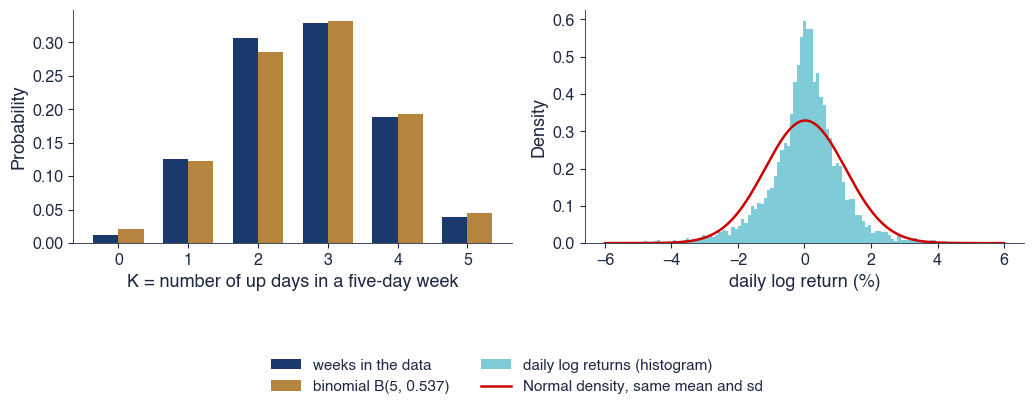

In [8]:
fig_random_variables(save=False)

{'n': 6714,
 'mean': np.float64(0.024718705886760773),
 'sd': 1.213029590053411,
 'q01_emp': -3.4546725026824543,
 'q01_norm': np.float64(-2.7972101020826243),
 'p3_emp': 0.015490020851951147,
 'p3_norm': 0.0063240971076023705,
 'p5_emp': 0.0034256776884122727,
 'p5_norm': 1.7192859488327813e-05,
 'median': 0.0634919919234811,
 'F0': 0.46276437295204054}

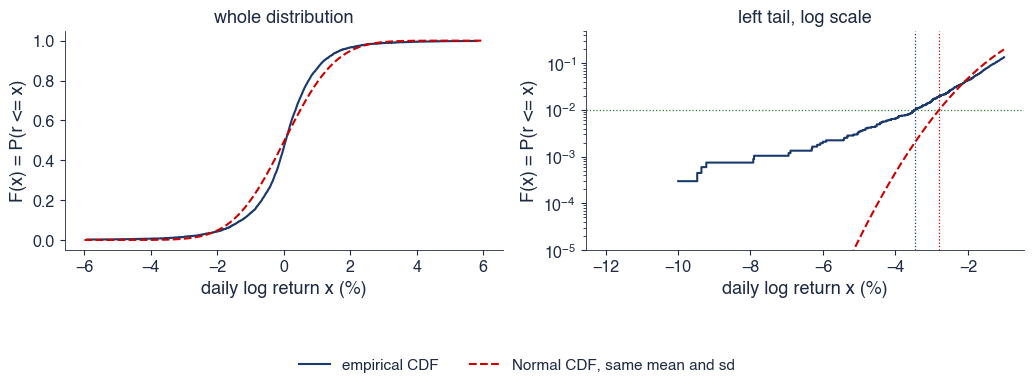

In [9]:
fig_cdf_quantile(save=False)

## 2. Joint distributions and dependence

- Covariance, correlation and the volatility of a 50/50 portfolio.
- Uncorrelated is not independent: $X$ and $X^2$; returns and squared returns.

In [10]:
def fig_joint(pairs=(('sp500', 'dax'), ('sp500', 'bet')), save=True):
    """Scatter plots of daily returns of two markets on common days (joint distribution) with the correlation."""
    fig, axes = plt.subplots(1, len(pairs), figsize=(10.5, 4.0))
    out = {}
    for ax, (a, b) in zip(axes, pairs):
        R = joint_returns(a, b)
        o = pair_stats(a, b)
        ax.scatter(R[a].clip(-12, 12), R[b].clip(-12, 12), s=3, alpha=0.35, color=COLORS[b],
                   label=f'{SHORT[a]} vs {SHORT[b]}: correlation {o["corr"]:.2f}')
        ax.axhline(0, color=st.DarkText, lw=0.5)
        ax.axvline(0, color=st.DarkText, lw=0.5)
        ax.set_xlabel(f'{SHORT[a]} daily log return (%)')
        ax.set_ylabel(f'{SHORT[b]} daily log return (%)')
        ax.set_xlim(-12, 12)
        ax.set_ylim(-12, 12)
        out[f'{a}_{b}'] = o
    st.fig_legend_bottom(fig, ncol=2, y=0.02)
    fig.tight_layout(rect=(0, 0.1, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch4_joint')
    return out


def fig_uncorrelated_dependent(names=ASSETS, seed=4, save=True):
    """Left: X ~ N(0,1) and Y = X^2 are uncorrelated but dependent. Right: for real returns, Corr(r_t, r_{t-1}) is
    close to zero while Corr(r_t^2, r_{t-1}^2) is clearly positive."""
    rng = np.random.default_rng(seed)
    X = rng.standard_normal(3000)
    Y = X ** 2
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), gridspec_kw={'width_ratios': [1, 1.3]})
    ax = axes[0]
    ax.scatter(X, Y, s=4, alpha=0.4, color=PAL['purple'], label=f'simulated: Y = X^2, Corr(X, Y) = {np.corrcoef(X, Y)[0, 1]:.3f}')
    ax.set_xlabel('X ~ N(0, 1)')
    ax.set_ylabel('Y = X^2')
    ax = axes[1]
    out = {'xy_corr': float(np.corrcoef(X, Y)[0, 1])}
    idx = np.arange(len(names))
    rr = [lag_dependence(returns(k)) for k in names]
    ax.bar(idx - 0.18, [o['rho_r'] for o in rr], width=0.36, color=PAL['blue'], label='Corr(r_t, r_{t-1})')
    ax.bar(idx + 0.18, [o['rho_r2'] for o in rr], width=0.36, color=PAL['red'], label='Corr(r_t^2, r_{t-1}^2)')
    for i, o in enumerate(rr):
        ax.plot([i - 0.42, i + 0.42], [o['band']] * 2, color=PAL['green'], lw=1.2, ls='--',
                label='i.i.d. band +/- 1.96/sqrt(n)' if i == 0 else '_')
        ax.plot([i - 0.42, i + 0.42], [-o['band']] * 2, color=PAL['green'], lw=1.2, ls='--', label='_')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_xticks(idx)
    ax.set_xticklabels([SHORT[k] for k in names])
    ax.set_ylabel('lag-1 correlation')
    for k, o in zip(names, rr):
        out[k] = o
    st.fig_legend_bottom(fig, ncol=2, y=0.02)
    fig.tight_layout(rect=(0, 0.14, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch4_uncorrelated_dependent')
    return out

,sp500_dax,sp500_bet
n,6605.0000,6466.0000
m1,0.0251,0.0262
m2,0.0200,0.0659
s1,1.2208,1.2294
s2,1.4288,1.4292
cov,1.0448,0.3745
corr,0.5990,0.2131
sd_p,1.1855,1.0372
sd_avg,1.3248,1.3293
var_sum,0.8830,0.8885


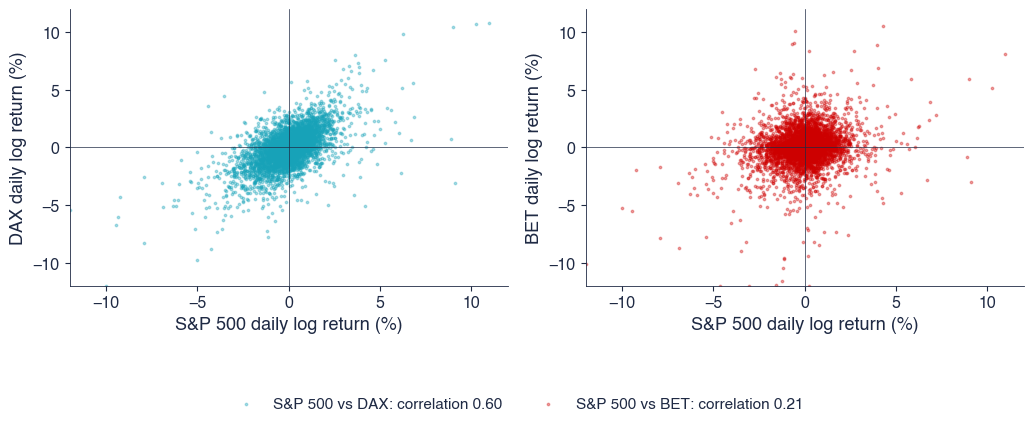

In [11]:
pd.DataFrame(fig_joint(save=False)).round(4)

{'xy_corr': -0.03757659791679318,
 'sp500': {'n': 6714,
  'rho_r': -0.09865785288466193,
  'rho_r2': 0.31332537710161545,
  'rho_abs': 0.2894433138743817,
  'band': np.float64(0.02392023284731494)},
 'dax': {'n': 6786,
  'rho_r': -0.016818136015201355,
  'rho_r2': 0.14869645082975655,
  'rho_abs': 0.2187786883664957,
  'band': np.float64(0.023792996663821505)},
 'bet': {'n': 6670,
  'rho_r': 0.10894644190136606,
  'rho_r2': 0.33069428148141594,
  'rho_abs': 0.40202352352242327,
  'band': np.float64(0.02399900047893674)},
 'btc': {'n': 4384,
  'rho_r': -0.02232377147441803,
  'rho_r2': 0.13670678050340074,
  'rho_abs': 0.21278628954460993,
  'band': np.float64(0.02960198257317867)}}

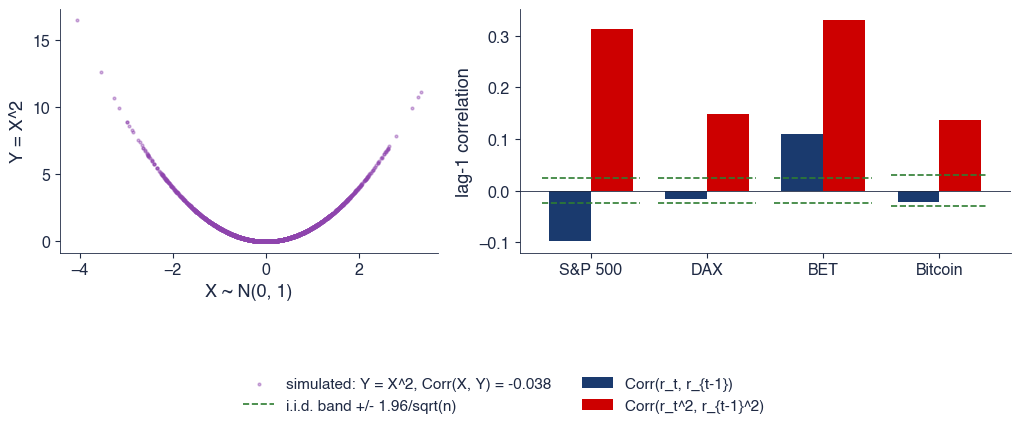

In [12]:
fig_uncorrelated_dependent(save=False)

## 3. Conditional expectation and conditional variance

- Mean and standard deviation of today's return by quintile of yesterday's absolute return.
- The law of total variance: within-quintile plus between-quintile variance.

In [13]:
def fig_conditional(names=('sp500', 'btc'), save=True):
    """Conditional mean and conditional standard deviation of today's return given the quintile of yesterday's
    absolute return."""
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.7))
    out = {}
    idx = np.arange(1, 6)
    for j, k in enumerate(names):
        c = conditional_moments(returns(k))
        out[k] = c
        off = -0.18 if j == 0 else 0.18
        axes[0].bar(idx + off, c['mean'], width=0.36, color=COLORS[k], label=SHORT[k])
        axes[1].bar(idx + off, c['sd'], width=0.36, color=COLORS[k], label='_')
        axes[1].plot([0.6, 5.4], [c['sd_all']] * 2, color=COLORS[k], lw=1.1, ls='--',
                     label=f'{SHORT[k]}: unconditional sd')
    axes[0].axhline(0, color=st.DarkText, lw=0.6)
    axes[0].set_ylabel('E[r_t | quintile] (%)')
    axes[1].set_ylabel('sd(r_t | quintile) (%)')
    for ax in axes:
        ax.set_xticks(idx)
        ax.set_xticklabels(['Q1\ncalm', 'Q2', 'Q3', 'Q4', 'Q5\nturbulent'])
        ax.set_xlabel('quintile of |r_{t-1}|')
    st.fig_legend_bottom(fig, ncol=4, y=0.02)
    fig.tight_layout(rect=(0, 0.1, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch4_conditional')
    return out

{'sp500': {'sd by quintile': array([0.91 , 0.982, 1.066, 1.215, 1.714]),
  'Q5/Q1': 1.88,
  'within': 1.469,
  'between': 0.00013},
 'btc': {'sd by quintile': array([3.281, 2.896, 3.239, 3.454, 4.363]),
  'Q5/Q1': 1.33,
  'within': 12.1219,
  'between': 0.01156}}

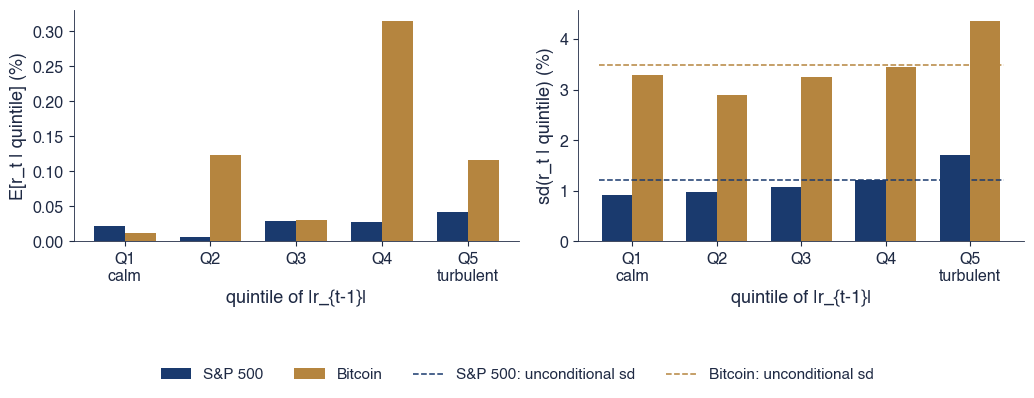

In [14]:
res = fig_conditional(save=False)
{k: {'sd by quintile': v['sd'].round(3), 'Q5/Q1': round(v['ratio'], 2), 'within': round(v['within'], 4), 'between': round(v['between'], 5)} for k, v in res.items()}

## 4. The law of large numbers and Monte Carlo

- The running mean of S&P 500 returns: the expected return is estimated very imprecisely.
- Monte Carlo estimate of a 21-day loss probability and its standard error $\sqrt{p(1-p)/N}$.

In [15]:
def fig_lln(name='sp500', n_sim=5, seed=11, save=True):
    """Law of large numbers: the running sample mean of daily returns, real and simulated i.i.d. Normal with the
    same mean and standard deviation, with the band mu +/- 1.96 sigma / sqrt(n)."""
    r = returns(name)
    m, s = r.mean(), r.std()
    n = np.arange(1, len(r) + 1)
    rng = np.random.default_rng(seed)
    fig, ax = plt.subplots(figsize=(10, 3.8))
    for i in range(n_sim):
        z = rng.normal(m, s, len(r))
        ax.plot(n, np.cumsum(z) / n, lw=0.9, alpha=0.8, color=st.PALETTE[2 + i % 5],
                label='simulated i.i.d. Normal, same mean and sd' if i == 0 else '_')
    ax.plot(n, np.cumsum(r.values) / n, color=PAL['blue'], lw=1.8, label=f'{SHORT[name]}: running mean')
    ax.plot(n, m + 1.96 * s / np.sqrt(n), color=PAL['red'], lw=1.1, ls='--', label='mean +/- 1.96 sd / sqrt(n)')
    ax.plot(n, m - 1.96 * s / np.sqrt(n), color=PAL['red'], lw=1.1, ls='--', label='_')
    ax.axhline(0, color=st.DarkText, lw=0.5)
    ax.set_ylim(-0.6, 0.6)
    ax.set_xscale('log')
    ax.set_xlabel('number of days n (log scale)')
    ax.set_ylabel('running mean of r_t (%)')
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch4_lln')
    ppy = periods_per_year(r)
    se = s / np.sqrt(len(r))
    return {'n': len(r), 'mean': m, 'sd': s, 'se': se, 't': m / se, 'ppy': ppy, 'years': len(r) / ppy,
            'mean_ann': m * ppy, 'se_ann': se * ppy, 'n_needed_halfse': 4 * len(r),
            'years_for_t3': (3 * s / m) ** 2 / ppy}


def mc_loss_probability(name='sp500', h=21, loss=10.0, N=10 ** 6, seed=5):
    """P(h-day log return < -loss %) under i.i.d. Normal daily log returns: exact value Phi((-loss - h m)/(s sqrt h))
    and the Monte Carlo estimate as a function of the number of simulations, with its standard error
    sqrt(p(1 - p)/N)."""
    r = returns(name)
    m, s = r.mean(), r.std()
    p = stats.norm.cdf((-loss - h * m) / (s * np.sqrt(h)))
    rng = np.random.default_rng(seed)
    sims = rng.normal(h * m, s * np.sqrt(h), N)          # the sum of h i.i.d. Normal returns is Normal
    hits = np.cumsum(sims < -loss)
    Ns = np.arange(1, N + 1)
    return {'p': p, 'm': m, 's': s, 'h': h, 'loss': loss, 'est': hits / Ns, 'Ns': Ns}


def fig_monte_carlo(name='sp500', save=True):
    """Monte Carlo estimate of the probability of a 21-day loss larger than 10% against the number of simulations,
    with the 95% band p +/- 1.96 sqrt(p(1 - p)/N)."""
    o = mc_loss_probability(name)
    p, est, Ns = o['p'], o['est'], o['Ns']
    fig, ax = plt.subplots(figsize=(10, 3.7))
    grid = np.unique(np.logspace(1, 6, 400).astype(int)) - 1
    ax.plot(Ns[grid], 100 * est[grid], color=PAL['blue'], lw=1.5, label='Monte Carlo estimate')
    band = 1.96 * np.sqrt(p * (1 - p) / Ns[grid])
    ax.fill_between(Ns[grid], 100 * (p - band), 100 * (p + band), color=PAL['teal'], alpha=0.2,
                    label='95% band p +/- 1.96 sqrt(p(1 - p)/N)')
    ax.axhline(100 * p, color=PAL['red'], lw=1.2, ls='--', label=f'exact value {100 * p:.3f}%')
    ax.set_xscale('log')
    ax.set_ylim(0, 3 * 100 * p)
    ax.set_xlabel('number of simulations N (log scale)')
    ax.set_ylabel('P(21-day loss > 10%) (%)')
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch4_monte_carlo')
    out = {'p': p, 'm': o['m'], 's': o['s']}
    for N in (100, 1000, 10000, 100000, 1000000):
        out[f'est_{N}'] = float(est[N - 1])
        out[f'se_{N}'] = float(np.sqrt(p * (1 - p) / N))
    out['N_rel10'] = int(np.ceil((1 - p) / p / 0.1 ** 2 * 1.96 ** 2))
    return out

{'n': 6714,
 'mean': np.float64(0.024718705886760773),
 'sd': 1.213029590053411,
 'se': np.float64(0.014804056247326825),
 't': np.float64(1.669725207321084),
 'ppy': 251.41362517941357,
 'years': 26.704996577686515,
 'mean_ann': np.float64(6.214619456734237),
 'se_ann': np.float64(3.7219414485003823),
 'n_needed_halfse': 26856,
 'years_for_t3': np.float64(86.20749563617045)}

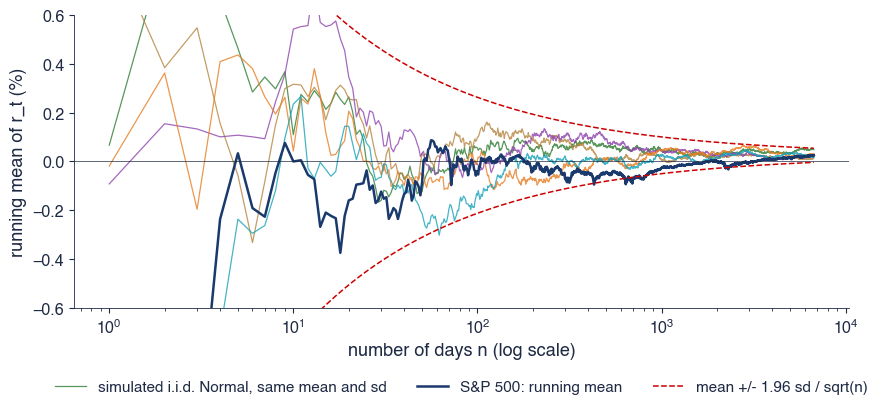

In [16]:
fig_lln(save=False)

{'p': np.float64(0.029223405585503254),
 'm': np.float64(0.024718705886760773),
 's': 1.213029590053411,
 'est_100': 0.02,
 'se_100': 0.01684321767106524,
 'est_1000': 0.03,
 'se_1000': 0.005326293096656288,
 'est_10000': 0.0295,
 'se_10000': 0.0016843217671065238,
 'est_100000': 0.02901,
 'se_100000': 0.0005326293096656288,
 'est_1000000': 0.029256,
 'se_1000000': 0.00016843217671065237,
 'N_rel10': 12762}

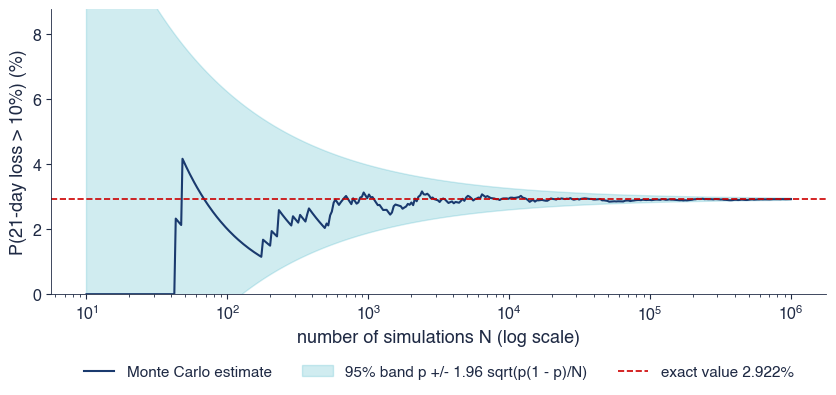

In [17]:
fig_monte_carlo(save=False)

## 5. Random number generators and the inverse transform

- Linear congruential generators and RANDU (ports of SFErangen1, SFErangen2 and SFErandu).
- The inverse transform: exponential, Normal and empirical (historical simulation).

In [18]:
def fig_randu(n=30000, seed=1, save=True):
    """RANDU: pairs (u_k, u_{k+1}) look uniform, but 9 u_k - 6 u_{k+1} + u_{k+2} takes only 15 integer values,
    so all triples lie on 15 parallel planes (Marsaglia, 1968). A modern generator (PCG64) has no such structure."""
    x, u = randu(n, seed)
    comb_int = (9 * x[:-2] - 6 * x[1:-1] + x[2:])
    assert np.all(comb_int % RANDU_M == 0)
    comb = comb_int // RANDU_M
    v = np.random.default_rng(seed).random(n)
    comb_pcg = 9 * v[:-2] - 6 * v[1:-1] + v[2:]
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
    axes[0].scatter(u[:-1][:5000], u[1:][:5000], s=1.5, color=PAL['blue'], alpha=0.6, label='RANDU pairs (u_k, u_{k+1})')
    axes[0].set_xlabel('u_k')
    axes[0].set_ylabel('u_{k+1}')
    vals, cnt = np.unique(comb, return_counts=True)
    axes[1].bar(vals, cnt / len(comb), width=0.5, color=PAL['red'], label='RANDU: 9u_k - 6u_{k+1} + u_{k+2}')
    axes[1].set_xlabel('value of the combination')
    axes[1].set_ylabel('share of triples')
    axes[2].hist(comb_pcg, bins=150, density=True, color=PAL['green'], alpha=0.75, label='PCG64: the same combination')
    axes[2].set_xlabel('value of the combination')
    axes[2].set_ylabel('density')
    st.fig_legend_bottom(fig, ncol=3, y=0.02)
    fig.tight_layout(rect=(0, 0.1, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch4_randu')
    x16, _ = lcg(5, 1, 16, 7, 18)
    return {'n_values': int(len(vals)), 'vmin': int(vals.min()), 'vmax': int(vals.max()),
            'corr_pairs': float(np.corrcoef(u[:-1], u[1:])[0, 1]), 'mean_u': float(u.mean()), 'var_u': float(u.var()),
            'lcg16': x16.tolist(), 'period16': lcg_period(5, 1, 16, 7), 'period_bad': lcg_period(4, 1, 16, 7)}


def fig_inverse_transform(name='sp500', n=200000, seed=3, save=True):
    """Inverse transform method: X = F^{-1}(U) with U ~ U(0, 1). Left: exponential draws -ln(1 - U)/lambda against
    the exponential density. Right: draws from the Normal quantile function and from the empirical quantile
    function of daily returns (historical simulation), on a log scale."""
    rng = np.random.default_rng(seed)
    U = rng.random(n)
    lam = 2.0
    E = -np.log(1 - U) / lam
    r = returns(name)
    m, s = r.mean(), r.std()
    N = m + s * stats.norm.ppf(U)
    H = np.quantile(r.values, U)                       # empirical quantile function
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.7))
    ax = axes[0]
    ax.hist(E, bins=120, range=(0, 3), density=True, color=PAL['amber'], alpha=0.6, label='-ln(1 - U)/2, histogram')
    x = np.linspace(0, 3, 300)
    ax.plot(x, lam * np.exp(-lam * x), color=PAL['blue'], lw=1.8, label='exponential density 2 exp(-2x)')
    ax.set_xlabel('x')
    ax.set_ylabel('density')
    ax = axes[1]
    bins = np.linspace(-12, 12, 121)
    ax.hist(N, bins=bins, density=True, histtype='step', color=PAL['red'], lw=1.5, label='Normal quantile of U')
    ax.hist(H, bins=bins, density=True, histtype='step', color=PAL['blue'], lw=1.5,
            label=f'empirical quantile of U ({SHORT[name]})')
    ax.set_yscale('log')
    ax.set_xlabel('simulated daily return (%)')
    ax.set_ylabel('density (log scale)')
    st.fig_legend_bottom(fig, ncol=2, y=0.02)
    fig.tight_layout(rect=(0, 0.13, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch4_inverse_transform')
    return {'lam': lam, 'mean_E': float(E.mean()), 'p5_norm': float((N < -5).mean()), 'p5_hist': float((H < -5).mean()),
            'p5_data': float((r < -5).mean()), 'n': n, 'min_hist': float(H.min()), 'min_norm': float(N.min())}

{'n_values': 15,
 'vmin': -5,
 'vmax': 9,
 'corr_pairs': 0.0031756461271969937,
 'mean_u': 0.5032783054227631,
 'var_u': 0.08323015083904704,
 'lcg16': [7, 4, 5, 10, 3, 0, 1, 6, 15, 12, 13, 2, 11, 8, 9, 14, 7, 4],
 'period16': 16,
 'period_bad': 1}

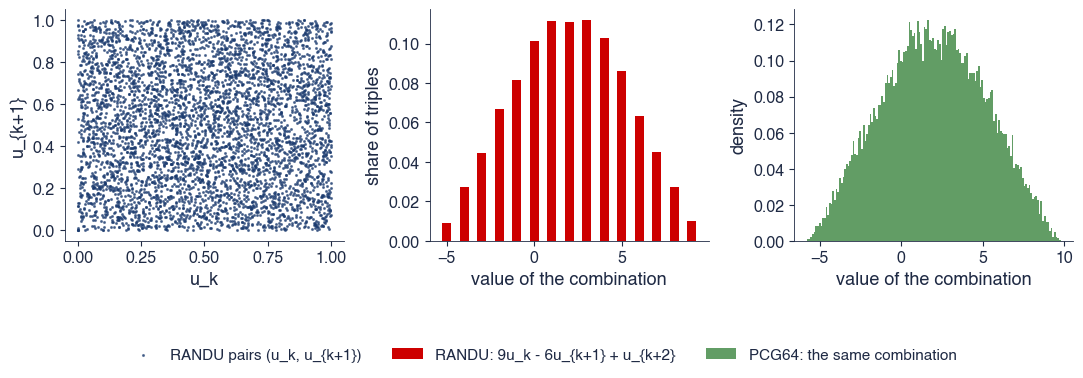

In [19]:
fig_randu(save=False)

{'lam': 2.0,
 'mean_E': 0.4998807969756758,
 'p5_norm': 3.5e-05,
 'p5_hist': 0.003425,
 'p5_data': 0.0034256776884122727,
 'n': 200000,
 'min_hist': -12.742498974327349,
 'min_norm': -5.6920887662680695}

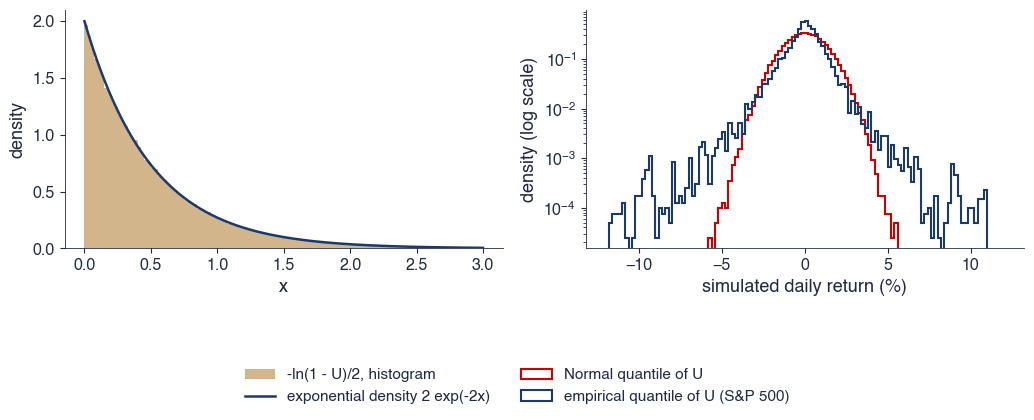

In [20]:
fig_inverse_transform(save=False)

## 6. The binomial process

- Cox-Ross-Rubinstein tree calibrated to the S&P 500 (port of SFEBinomp).

In [21]:
def fig_binomial(name='sp500', S0=100.0, T=1.0, n=252, n_paths=12, seed=8, save=True):
    """Binomial process (Cox-Ross-Rubinstein, port of SFEBinomp) calibrated to the volatility and drift of an index:
    sample paths over one year of daily steps and the distribution of S_T against the lognormal limit."""
    g = gbm_params(returns(name))
    B = binomial_crr(S0, g['mu'], g['sigma'], T, n)
    rng = np.random.default_rng(seed)
    steps = np.where(rng.random((n_paths, n)) < B['p'], np.log(B['u']), np.log(B['d']))
    paths = S0 * np.exp(np.hstack([np.zeros((n_paths, 1)), np.cumsum(steps, axis=1)]))
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.7), gridspec_kw={'width_ratios': [1.4, 1]})
    t = np.arange(n + 1)
    for i in range(n_paths):
        axes[0].plot(t, paths[i], lw=0.9, color=st.PALETTE[i % len(st.PALETTE)], label='binomial paths' if i == 0 else '_')
    axes[0].set_xlabel('trading day')
    axes[0].set_ylabel('S_t')
    S, pr = B['S'], B['prob']
    keep = pr > 1e-6
    widths = np.diff(np.log(S))[0]
    dens = pr / (S * widths)                           # probability per unit of S
    axes[1].bar(S[keep], dens[keep], width=S[keep] * widths * 0.9, color=PAL['amber'], alpha=0.7,
                label='binomial distribution of S_T')
    x = np.linspace(S[keep].min(), S[keep].max(), 400)
    ml, sl = np.log(S0) + (g['mu'] - g['sigma'] ** 2 / 2) * T, g['sigma'] * np.sqrt(T)
    axes[1].plot(x, stats.lognorm.pdf(x, sl, scale=np.exp(ml)), color=PAL['blue'], lw=1.8, label='lognormal limit')
    axes[1].set_xlabel('S_T')
    axes[1].set_ylabel('density')
    st.fig_legend_bottom(fig, ncol=3, y=0.02)
    fig.tight_layout(rect=(0, 0.1, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch4_binomial')
    ES = float((S * pr).sum())
    return {'u': B['u'], 'd': B['d'], 'p': B['p'], 'mu': g['mu'], 'sigma': g['sigma'], 'mu_log': g['mu_log'],
            'ES': ES, 'ES_th': S0 * np.exp(g['mu'] * T), 'ploss_bin': float(pr[S < S0].sum()),
            'ploss_ln': float(stats.norm.cdf((np.log(S0) - ml) / sl)), 'n': n,
            'q05_bin': float(S[np.searchsorted(np.cumsum(pr), 0.05)]), 'q05_ln': float(np.exp(ml + sl * stats.norm.ppf(0.05)))}

{'u': np.float64(1.0121898729758643),
 'd': np.float64(0.9879569305114407),
 'p': np.float64(0.5101787966999807),
 'mu': np.float64(0.08064320768393635),
 'sigma': np.float64(0.1923383119224767),
 'mu_log': np.float64(0.06214619456734237),
 'ES': 108.39840703754943,
 'ES_th': np.float64(108.39840703755121),
 'ploss_bin': 0.3972216029762831,
 'ploss_ln': 0.37330643596751323,
 'n': 252,
 'q05_bin': 78.48022563399466,
 'q05_ln': 77.55194815534239}

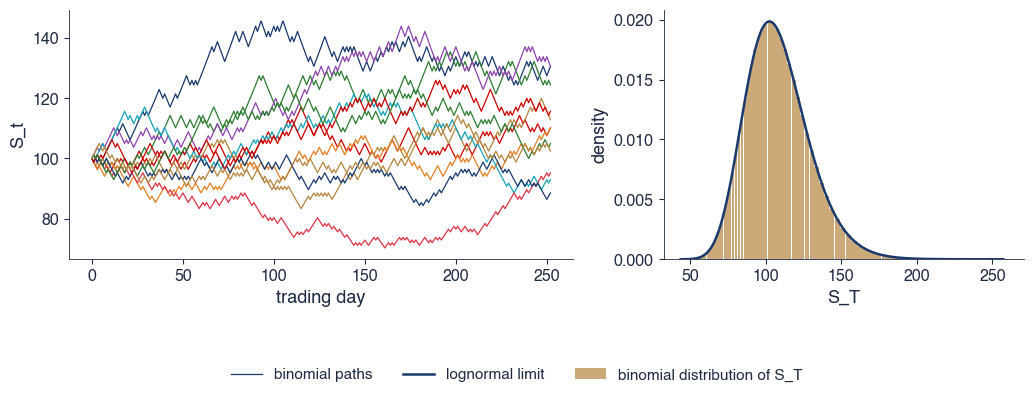

In [22]:
fig_binomial(save=False)

## 7. Discrete-time processes

- White noise, AR(1) and random walk driven by the same shocks.
- Which one is real? The S&P 500 among three GBM paths.

In [23]:
def fig_processes(n=500, seed=21, save=True):
    """White noise, random walk and AR(1) processes driven by the same shocks eps_t ~ N(0, 1)."""
    rng = np.random.default_rng(seed)
    eps = rng.standard_normal(n)
    series = [('white noise eps_t', eps, PAL['purple']),
              ('AR(1), phi = 0.5', ar1(0.5, eps), PAL['green']),
              ('AR(1), phi = 0.95', ar1(0.95, eps), PAL['amber']),
              ('random walk (phi = 1)', ar1(1.0, eps), PAL['red'])]
    fig, axes = plt.subplots(2, 2, figsize=(10.5, 4.6), sharex=True)
    for ax, (lab, x, c) in zip(axes.ravel(), series):
        ax.plot(x, color=c, lw=0.9, label=lab)
        ax.axhline(0, color=st.DarkText, lw=0.5)
        ax.set_title(lab)
    for ax in axes[1]:
        ax.set_xlabel('t')
    st.fig_legend_bottom(fig, ncol=4, y=0.02)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch4_processes')
    # long simulation for the moments
    e2 = np.random.default_rng(seed + 1).standard_normal(200000)
    out = {}
    for phi in (0.5, 0.95):
        x = ar1(phi, e2)[1000:]
        out[str(phi)] = {'var': float(x.var()), 'var_th': 1 / (1 - phi ** 2), 'rho1': float(acf(x, 1)[0]),
                         'rho5': float(acf(x, 5)[4]), 'rho5_th': phi ** 5, 'half_life': np.log(0.5) / np.log(phi)}
    rw = np.cumsum(np.random.default_rng(seed + 2).standard_normal((5000, 100)), axis=1)
    out['rw_var'] = {str(t): float(rw[:, t - 1].var()) for t in (10, 50, 100)}
    return out


def fig_spot_the_real(name='sp500', real_pos=2, seed=31, save=True):
    """Which one is real? An index (log price and daily returns) among three GBM paths with the same drift and
    volatility (i.i.d. Normal log returns)."""
    P = load_close(name, START)
    r = 100 * np.log(P).diff().dropna()
    m, s = r.mean(), r.std()
    rng = np.random.default_rng(seed)
    panels = []
    for i in range(4):
        if i == real_pos:
            panels.append(r.values)
        else:
            panels.append(rng.normal(m, s, len(r)))
    fig, axes = plt.subplots(2, 4, figsize=(11, 4.4), sharey='row')
    for i, x in enumerate(panels):
        lp = np.log(P.iloc[0]) + np.concatenate([[0], np.cumsum(x) / 100])
        axes[0, i].plot(np.exp(lp), color=PAL['blue'], lw=0.9)
        axes[0, i].set_yscale('log')
        axes[0, i].set_title('ABCD'[i])
        axes[1, i].plot(x, color=PAL['red'], lw=0.5)
        axes[1, i].set_xlabel('trading day')
        axes[0, i].set_xticks([])
    axes[0, 0].set_ylabel('price (log scale)')
    axes[1, 0].set_ylabel('daily return (%)')
    fig.tight_layout()
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch4_spot_the_real')
    k = [stats.kurtosis(x) for x in panels]
    a2 = [acf(np.asarray(x) ** 2, 1)[0] for x in panels]
    return {'real': 'ABCD'[real_pos], 'kurt': k, 'acf2': a2, 'mean': m, 'sd': s, 'n': len(r),
            'max_abs_real': float(np.abs(r).max()), 'max_abs_sim': float(max(np.abs(x).max() for j, x in enumerate(panels) if j != real_pos))}

{'0.5': {'var': 1.335359331499636,
  'var_th': 1.3333333333333333,
  'rho1': 0.4993953456015468,
  'rho5': 0.034070173177737736,
  'rho5_th': 0.03125,
  'half_life': np.float64(1.0)},
 '0.95': {'var': 10.196610686756038,
  'var_th': 10.256410256410254,
  'rho1': 0.9495777299862067,
  'rho5': 0.7723996082369532,
  'rho5_th': 0.7737809374999998,
  'half_life': np.float64(13.513407333964874)},
 'rw_var': {'10': 10.088634550546432,
  '50': 49.82458882433297,
  '100': 100.86549144574546}}

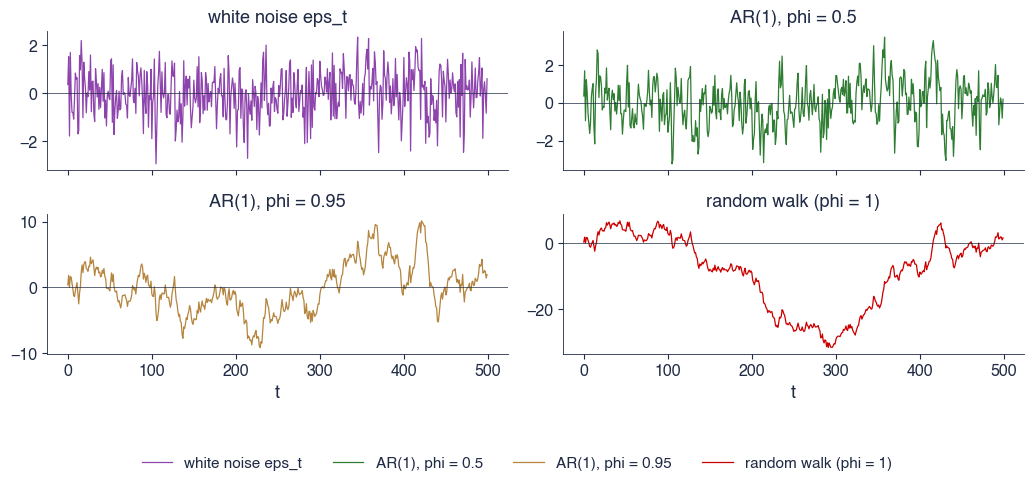

In [24]:
fig_processes(save=False)

the real series is column C


,excess kurtosis,"Corr(r_t^2, r_t-1^2)"
A,0.025,-0.001
B,-0.016,0.006
C,10.666,0.313
D,0.003,0.003


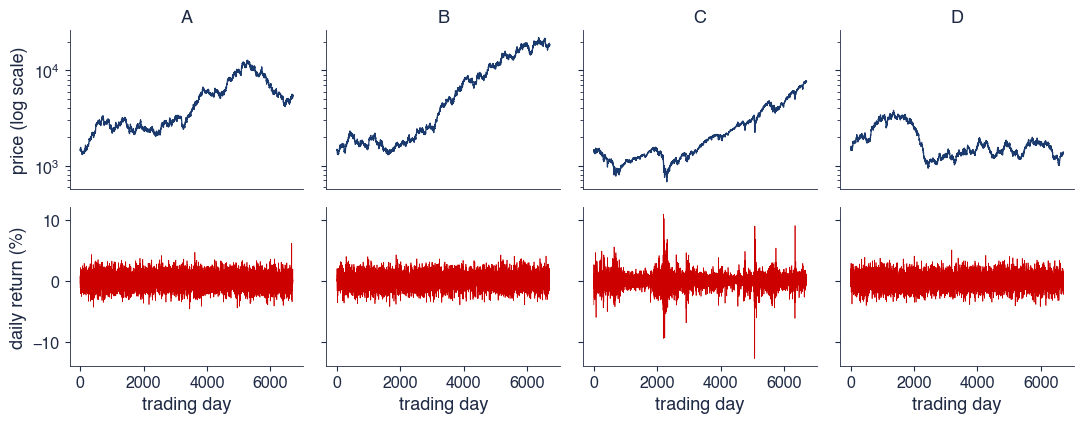

In [25]:
out = fig_spot_the_real(save=False)
print('the real series is column', out['real'])
pd.DataFrame({'excess kurtosis': out['kurt'], 'Corr(r_t^2, r_t-1^2)': out['acf2']}, index=list('ABCD')).round(3)

## 8. The Wiener process and geometric Brownian motion

- Scaled random walks converge to the Wiener process (port of SFEWienerProcess).
- GBM calibrated to the S&P 500 (port of SFEsimGBM); real paths in GBM fans; what GBM misses.

In [26]:
def scaled_random_walk(n, rng):
    """Scaled random walk on [0, 1]: W_n(t) = (eps_1 + ... + eps_[nt]) / sqrt(n), eps = +/-1 with probability 1/2."""
    e = rng.choice([-1.0, 1.0], n)
    return np.linspace(0, 1, n + 1), np.concatenate([[0], np.cumsum(e)]) / np.sqrt(n)


def fig_wiener(n_paths=20, seed=13, save=True):
    """Left: scaled random walks with 10, 100 and 10,000 steps (Donsker). Right: Wiener paths on [0, 1] with the
    bands +/- sqrt(t) and +/- 2 sqrt(t). Port of SFEWienerProcess."""
    rng = np.random.default_rng(seed)
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
    for n, c in [(10, PAL['amber']), (100, PAL['green']), (10000, PAL['blue'])]:
        t, w = scaled_random_walk(n, rng)
        axes[0].step(t, w, where='post', color=c, lw=1.1 if n < 10000 else 0.8, label=f'n = {n} steps')
    axes[0].set_xlabel('t')
    axes[0].set_ylabel('W_n(t)')
    steps = 1000
    t = np.linspace(0, 1, steps + 1)
    dW = rng.standard_normal((n_paths, steps)) * np.sqrt(1 / steps)
    W = np.hstack([np.zeros((n_paths, 1)), np.cumsum(dW, axis=1)])
    for i in range(n_paths):
        axes[1].plot(t, W[i], lw=0.7, color=st.PALETTE[i % len(st.PALETTE)], alpha=0.85, label='Wiener paths' if i == 0 else '_')
    for k, ls in [(1, '--'), (2, ':')]:
        axes[1].plot(t, k * np.sqrt(t), color=st.DarkText, lw=1.1, ls=ls, label=f'+/- {k} sqrt(t)')
        axes[1].plot(t, -k * np.sqrt(t), color=st.DarkText, lw=1.1, ls=ls, label='_')
    axes[1].set_xlabel('t')
    axes[1].set_ylabel('W(t)')
    st.fig_legend_bottom(fig, ncol=6, y=0.02)
    fig.tight_layout(rect=(0, 0.1, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch4_wiener')
    big = np.cumsum(np.random.default_rng(seed + 1).standard_normal((10000, 1000)) * np.sqrt(1 / 1000), axis=1)
    qv = np.sum(np.diff(np.concatenate([np.zeros((10000, 1)), big], axis=1), axis=1) ** 2, axis=1)
    return {'var_W1': float(big[:, -1].var()), 'var_Wh': float(big[:, 499].var()), 'qv_mean': float(qv.mean()),
            'qv_sd': float(qv.std()), 'share_in_1': float(np.mean(np.abs(big[:, -1]) < 1)),
            'cov_half_one': float(np.mean(big[:, 499] * big[:, -1]))}


def fig_gbm_paths(name='sp500', S0=100.0, T=10.0, n_paths=40, seed=17, save=True):
    """GBM paths calibrated to an index (port of SFEsimGBM), with the mean S_0 exp(mu t) and the median
    S_0 exp((mu - sigma^2/2) t)."""
    g = gbm_params(returns(name))
    steps = int(T * 252)
    S = simulate_gbm(S0, g['mu'], g['sigma'], T, steps, n_paths, seed)
    t = np.linspace(0, T, steps + 1)
    fig, ax = plt.subplots(figsize=(10, 3.9))
    for i in range(n_paths):
        ax.plot(t, S[i], lw=0.6, alpha=0.7, color=st.PALETTE[i % len(st.PALETTE)], label='GBM paths' if i == 0 else '_')
    ax.plot(t, S0 * np.exp(g['mu'] * t), color=st.DarkText, lw=2.2, label='mean S_0 exp(mu t)')
    ax.plot(t, S0 * np.exp((g['mu'] - g['sigma'] ** 2 / 2) * t), color=PAL['crimson'], lw=2.2, ls='--',
            label='median S_0 exp((mu - sigma^2/2) t)')
    ax.set_yscale('log')
    ax.set_xlabel('years')
    ax.set_ylabel('S_t (log scale)')
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch4_gbm_paths')
    big = simulate_gbm(S0, g['mu'], g['sigma'], T, 10, 200000, seed + 1)[:, -1]
    mean_T = S0 * np.exp(g['mu'] * T)
    return {**g, 'mean_T': mean_T, 'median_T': S0 * np.exp((g['mu'] - g['sigma'] ** 2 / 2) * T),
            'share_below_mean': float(np.mean(big < mean_T)),
            'share_below_mean_th': float(stats.norm.cdf(g['sigma'] * np.sqrt(T) / 2)),
            'ploss_T': float(stats.norm.cdf(-(g['mu'] - g['sigma'] ** 2 / 2) * np.sqrt(T) / g['sigma'])), 'T': T}


def fig_gbm_fan(names=('sp500', 'bet', 'btc'), n_paths=4000, seed=19, save=True):
    """Real price paths against the fan of a GBM calibrated to the same series (5%, 25%, 50%, 75% and 95%
    quantiles of S_t), started at the first day."""
    fig, axes = plt.subplots(1, len(names), figsize=(11, 3.7))
    out = {}
    for ax, k in zip(axes, names):
        P = load_close(k, max(START, SERIES[k][4]))
        r = 100 * np.log(P).diff().dropna()
        g = gbm_params(r)
        n = len(r)
        rng = np.random.default_rng(seed)
        z = rng.normal(r.mean() / 100, r.std() / 100, (n_paths, n))
        lp = np.log(P.iloc[0]) + np.hstack([np.zeros((n_paths, 1)), np.cumsum(z, axis=1)])
        q = np.quantile(lp, [0.05, 0.25, 0.5, 0.75, 0.95], axis=0)
        x = P.index
        ax.fill_between(x, np.exp(q[0]), np.exp(q[4]), color=COLORS[k], alpha=0.22, label='GBM 5%-95%')
        ax.fill_between(x, np.exp(q[1]), np.exp(q[3]), color=COLORS[k], alpha=0.3, label='GBM 25%-75%')
        ax.plot(x, np.exp(q[2]), color=COLORS[k], lw=1.0, ls='--', label='GBM median')
        ax.plot(x, P.values, color=st.DarkText, lw=1.0, label='real path')
        ax.set_yscale('log')
        ax.set_title(SHORT[k])
        ax.tick_params(axis='x', labelrotation=30)
        rank = (lp < np.log(P.values)[None, :]).mean(axis=0)
        out[k] = {**g, 'outside90': float(np.mean((rank < 0.05) | (rank > 0.95))), 'min_rank': float(rank[n // 20:].min()),
                  'min_rank_date': P.index[n // 20 + int(np.argmin(rank[n // 20:]))].date().isoformat(),
                  'max_rank': float(rank[n // 20:].max()), 'first': P.index[0].date().isoformat()}
    axes[0].set_ylabel('price (log scale)')
    handles = [plt.Rectangle((0, 0), 1, 1, color=PAL['blue'], alpha=0.22), plt.Rectangle((0, 0), 1, 1, color=PAL['blue'], alpha=0.3),
               plt.Line2D([], [], color=PAL['blue'], ls='--'), plt.Line2D([], [], color=st.DarkText)]
    st.fig_legend_bottom(fig, handles, ['GBM 5%-95% (series colour)', 'GBM 25%-75%', 'GBM median', 'real path'], ncol=4, y=0.02)
    fig.tight_layout(rect=(0, 0.1, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch4_gbm_fan')
    return out


def gbm_check(name, n_sims=300, seed=23):
    """Real series against GBM simulations of the same length, drift and volatility: excess kurtosis of daily
    returns, lag-1 autocorrelation of squared returns, number of 4-sigma days and the maximum drawdown."""
    P = load_close(name, max(START, SERIES[name][4]))
    r = 100 * np.log(P).diff().dropna()
    m, s, n = r.mean(), r.std(), len(r)
    rng = np.random.default_rng(seed)
    K, A, F, DD = [], [], [], []
    for _ in range(n_sims):
        x = rng.normal(m, s, n)
        K.append(stats.kurtosis(x))
        A.append(acf(x ** 2, 1)[0])
        F.append(int((np.abs(x - x.mean()) > 4 * x.std()).sum()))
        DD.append(max_drawdown(np.exp(np.cumsum(x) / 100)))
    real = {'kurt': float(stats.kurtosis(r)), 'acf2': float(acf(r.values ** 2, 1)[0]),
            'four': int((np.abs(r - m) > 4 * s).sum()), 'dd': max_drawdown(P.values)}
    sims = {k: np.asarray(v) for k, v in [('kurt', K), ('acf2', A), ('four', F), ('dd', DD)]}
    out = {'n': n, 'real': real}
    for k, v in sims.items():
        out[k] = {'q05': float(np.quantile(v, 0.05)), 'q50': float(np.median(v)), 'q95': float(np.quantile(v, 0.95)),
                  'rank': float(np.mean(v <= real[k]))}
    return out


def fig_gbm_check(names=('sp500', 'bet', 'btc'), save=True):
    """What GBM misses: excess kurtosis, lag-1 autocorrelation of squared returns and maximum drawdown of the real
    series against the 5%-95% range of 300 GBM simulations of the same length."""
    res = {k: gbm_check(k) for k in names}
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
    stats_ = [('kurt', 'excess kurtosis'), ('acf2', 'Corr(r_t^2, r_{t-1}^2)'), ('dd', 'maximum drawdown')]
    idx = np.arange(len(names))
    for ax, (key, lab) in zip(axes, stats_):
        for i, k in enumerate(names):
            o = res[k][key]
            ax.plot([i, i], [o['q05'], o['q95']], color=PAL['teal'], lw=6, alpha=0.6,
                    label='GBM simulations, 5%-95%' if i == 0 else '_', solid_capstyle='butt')
            ax.plot(i, o['q50'], marker='_', ms=16, color=PAL['teal'], label='GBM median' if i == 0 else '_')
            ax.plot(i, res[k]['real'][key], marker='o', ms=8, color=COLORS[k], ls='none',
                    label='real series' if i == 0 else '_')
        ax.set_xticks(idx)
        ax.set_xticklabels([SHORT[k] for k in names])
        ax.set_title(lab)
        ax.set_xlim(-0.5, len(names) - 0.5)
    axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{100 * v:.0f}%'))
    st.fig_legend_bottom(fig, ncol=3, y=0.02)
    fig.tight_layout(rect=(0, 0.1, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch4_gbm_check')
    return res

{'var_W1': 1.0055785780033126,
 'var_Wh': 0.49996144152740635,
 'qv_mean': 0.9993808614703081,
 'qv_sd': 0.04471819232093681,
 'share_in_1': 0.6824,
 'cov_half_one': 0.49558390136191194}

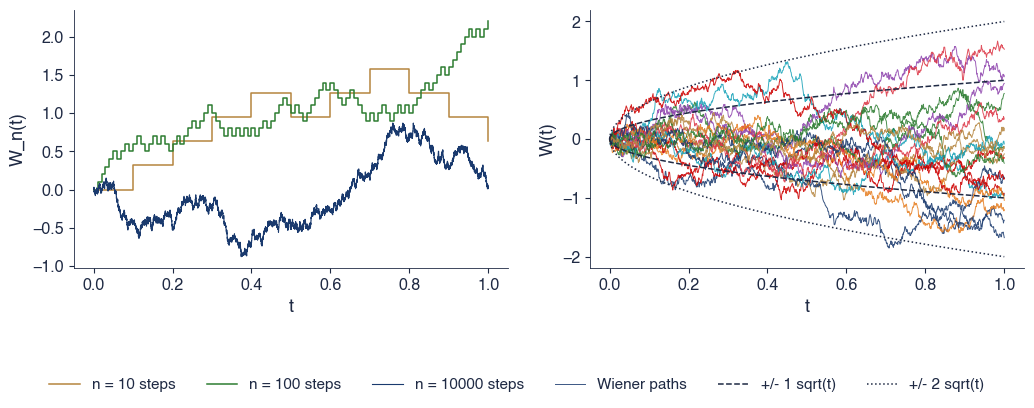

In [27]:
fig_wiener(save=False)

{'mu_log': np.float64(0.06214619456734237),
 'sigma': np.float64(0.1923383119224767),
 'mu': np.float64(0.08064320768393635),
 'ppy': 251.41362517941357,
 'n': 6714,
 'mean_T': np.float64(223.99019147257548),
 'median_T': np.float64(186.16476811523967),
 'share_below_mean': 0.619875,
 'share_below_mean_th': 0.6194793169276286,
 'ploss_T': 0.15344733993111076,
 'T': 10.0}

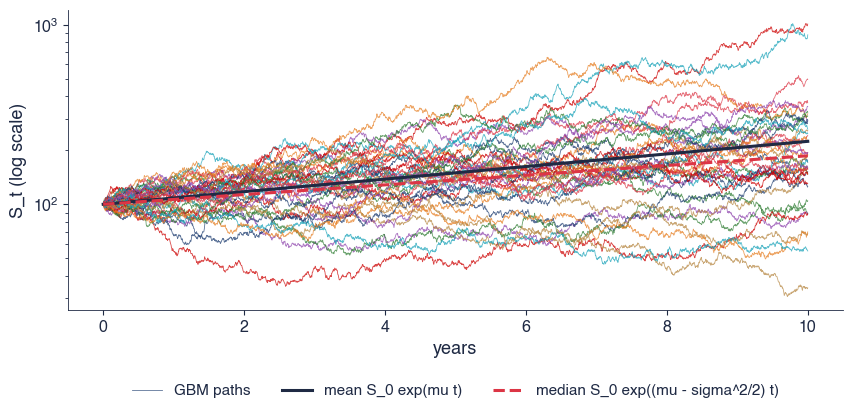

In [28]:
fig_gbm_paths(save=False)

{'sp500': {'mu_log': np.float64(0.06214619456734237),
  'sigma': np.float64(0.1923383119224767),
  'mu': np.float64(0.08064320768393635),
  'ppy': 251.41362517941357,
  'n': 6714,
  'outside90': 0.06999255398361877,
  'min_rank': 0.0055,
  'min_rank_date': '2002-07-23',
  'max_rank': 0.51775,
  'first': '2000-01-03'},
 'bet': {'mu_log': np.float64(0.15971128299187604),
  'sigma': np.float64(0.22106331764504483),
  'mu': np.float64(0.18414577819599304),
  'ppy': 249.81721698113208,
  'n': 6670,
  'outside90': 0.24059361415080197,
  'min_rank': 0.30575,
  'min_rank_date': '2020-03-23',
  'max_rank': 0.9995,
  'first': '2000-01-05'},
 'btc': {'mu_log': np.float64(0.4312977626280773),
  'sigma': np.float64(0.6661490053724957),
  'mu': np.float64(0.6531750113074599),
  'ppy': 365.3333333333333,
  'n': 4384,
  'outside90': 0.04538198403648803,
  'min_rank': 0.026,
  'min_rank_date': '2015-04-26',
  'max_rank': 0.97175,
  'first': '2014-09-17'}}

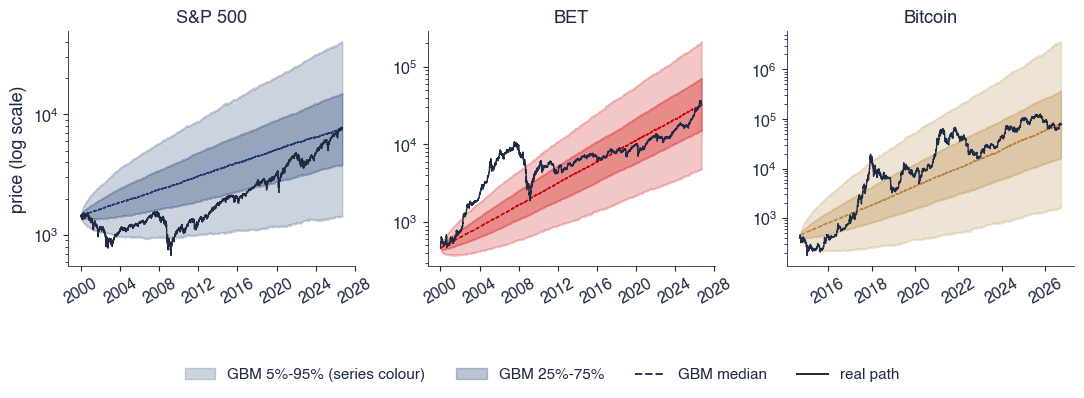

In [29]:
fig_gbm_fan(save=False)

,sp500,bet,btc
kurt,10.666,11.063,11.958
acf2,0.313,0.330,0.137
four,46.000,51.000,29.000
dd,-0.568,-0.825,-0.834


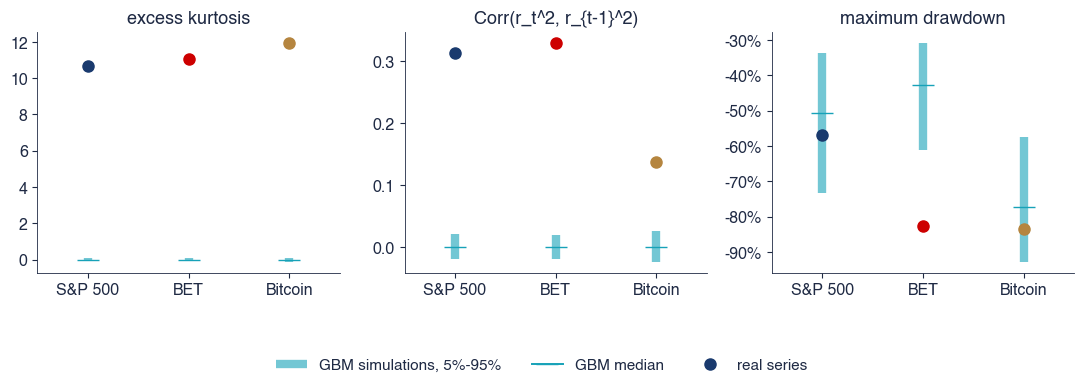

In [30]:
res = fig_gbm_check(save=False)
pd.DataFrame({k: v['real'] for k, v in res.items()}).round(3)

## 9. AI for scientific discovery: does GBM get drawdown risk right?

- Open question: how often does a calendar year contain a drawdown beyond 20% or 40%, in data and under GBM?
- Starter code: within-year maximum drawdowns and their GBM distribution.
- Things to check before trusting any answer, yours or an AI's: the definition of the drawdown, the calibration, the small number of years, and the effect of volatility clustering.

In [31]:
def gbm_yearly_drawdown(name, threshold=-0.20, n_paths=20000, seed=29):
    """Probability that a GBM calibrated to the series has a drawdown deeper than `threshold` within one year
    (daily steps), and the simulated distribution of the one-year maximum drawdown."""
    r = returns(name)
    g = gbm_params(r)
    steps = int(round(g['ppy']))
    S = simulate_gbm(1.0, g['mu'], g['sigma'], 1.0, steps, n_paths, seed)
    dd = np.min(S / np.maximum.accumulate(S, axis=1) - 1, axis=1)
    return {'p': float(np.mean(dd < threshold)), 'p40': float(np.mean(dd < 2 * threshold)), 'dd': dd,
            'sigma': g['sigma'], 'mu': g['mu']}


def fig_drawdown_years(names=('sp500', 'bet', 'btc'), threshold=-0.20, save=True):
    """Open question: within-year maximum drawdowns of real indices (dots, one per calendar year) against the
    GBM distribution (density); share of years with a drawdown beyond 20% in the data and under GBM."""
    fig, axes = plt.subplots(1, len(names), figsize=(11, 3.6))
    out = {}
    for ax, k in zip(axes, names):
        yd = yearly_drawdowns(k)
        g = gbm_yearly_drawdown(k, threshold)
        ax.hist(100 * g['dd'], bins=60, density=True, color=COLORS[k], alpha=0.55, label='GBM: one-year maximum drawdown')
        ax.plot(100 * yd.values, np.full(len(yd), 0.002), marker='|', ms=18, mew=2, ls='none', color=st.DarkText,
                label='real calendar years')
        ax.axvline(100 * threshold, color=PAL['red'], lw=1.2, ls='--', label='-20%')
        ax.set_title(SHORT[k])
        ax.set_xlabel('maximum drawdown within the year (%)')
        worst = yd.idxmin()
        out[k] = {'p_gbm': g['p'], 'share_real': float(np.mean(yd < threshold)), 'n_years': int(len(yd)),
                  'n_hit': int((yd < threshold).sum()), 'years_hit': [int(y) for y in yd.index[yd < threshold]],
                  'worst': float(yd.min()), 'worst_year': int(worst), 'median_real': float(yd.median()),
                  'median_gbm': float(np.median(g['dd'])), 'sigma': g['sigma'], 'p40_gbm': g['p40'],
                  'n_hit40': int((yd < 2 * threshold).sum()), 'exp40': g['p40'] * len(yd),
                  'q10_real': float(yd.quantile(0.1)), 'q10_gbm': float(np.quantile(g['dd'], 0.1)),
                  'binom_p': float(stats.binom.sf(int((yd < threshold).sum()) - 1, len(yd), g['p']))}
    axes[0].set_ylabel('density')
    st.fig_legend_bottom(fig, ncol=3, y=0.02)
    fig.tight_layout(rect=(0, 0.1, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch4_drawdown_years')
    return out

,sp500,bet,btc
n_years,26.0000,26.0000,11.0000
share_real,0.2308,0.4615,1.0000
p_gbm,0.3362,0.3389,0.9982
n_hit40,1.0000,1.0000,6.0000
p40_gbm,0.0053,0.0064,0.6232
binom_p,0.9148,0.1335,0.9798


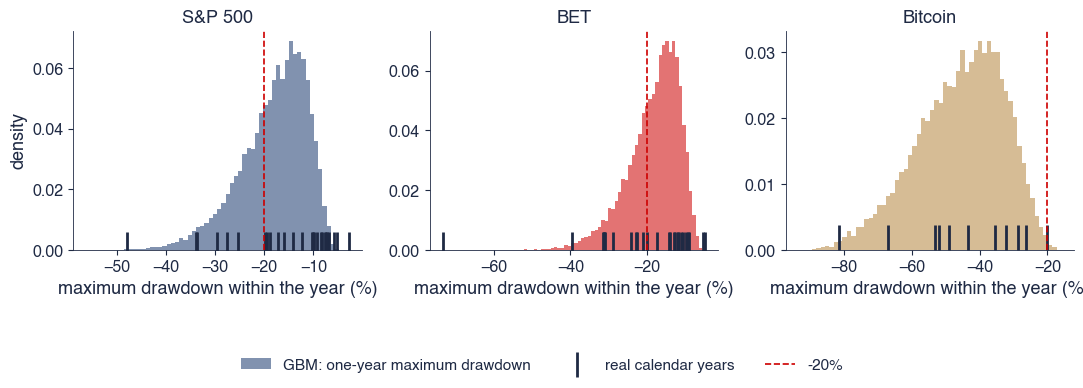

In [32]:
res = fig_drawdown_years(save=False)
pd.DataFrame({k: {c: v[c] for c in ['n_years', 'share_real', 'p_gbm', 'n_hit40', 'p40_gbm', 'binom_p']} for k, v in res.items()}).round(4)